<a href="https://colab.research.google.com/github/karsarobert/DeepLearning2026/blob/main/deep_learning_lab_3_spiral_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Practical Session

## Practical Session 3: TensorFlow, Multi-Class Classification
### September 17, 2025

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generating Synthetic Multi-Class Spiral Data

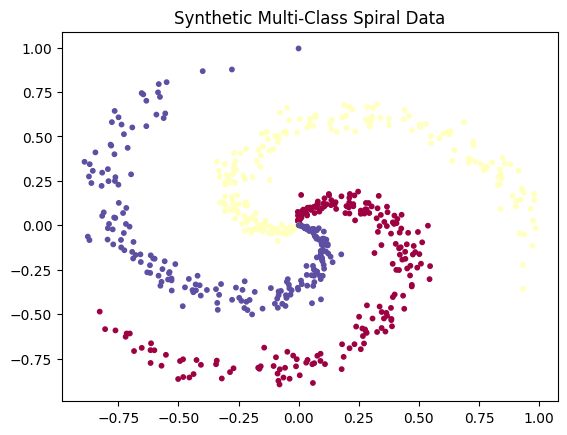

In [ ]:
N = 200 # number of points per class
D = 2   # dimensionality (features)
K = 3   # number of classes
X = np.zeros((N*K, D))           # data matrix (each row = single sample)
y = np.zeros(N*K, dtype='uint8') # class labels

for j in range(K):
    ix = range(N*j, N*(j+1))
    r = np.linspace(0.0, 1, N) # radius
    t = np.linspace(j*4, (j+1)*4, N) + np.random.randn(N)*0.2 # theta angle
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
    y[ix] = j

# Visualize the synthetic dataset
plt.scatter(X[:, 0], X[:, 1], c=y, s=10, cmap=plt.cm.Spectral)
plt.title('Synthetic Multi-Class Spiral Data')
plt.show()

In [ ]:
# Class labels are represented as discrete integers (0, 1, 2)
y[190:210]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=uint8)

In [ ]:
X.shape

(600, 2)

# Data Preprocessing and One-Hot Encoding

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

# Convert categorical labels to one-hot encoded matrix
y = tf.keras.utils.to_categorical(y, 3)

# Split into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
print('Shapes:', X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# Determine the number of input features
n_features = X_train.shape[1]

Shapes: (402, 2) (198, 2) (402, 3) (198, 3)


In [ ]:
y[190:210]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]])

# Neural Network Model Definition

In [ ]:
# Define sequential model
model = Sequential()
model.add(Dense(50, activation='relu', kernel_initializer='glorot_normal', input_shape=(n_features,)))
model.add(Dense(50, activation='relu', kernel_initializer='glorot_normal'))
model.add(Dense(3, activation='softmax'))

# Compile the model:
# Categorical crossentropy expects one-hot encoded target vectors (e.g. [[0,0,1], [1,0,0], [0,1,0]])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Note: Use sparse_categorical_crossentropy if integer labels are preserved instead.

# Fit the model
history = model.fit(X_train, y_train, epochs=150, validation_data=(X_test, y_test), batch_size=32, verbose=0)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Model Performance Evaluation

Test Accuracy: 0.995
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


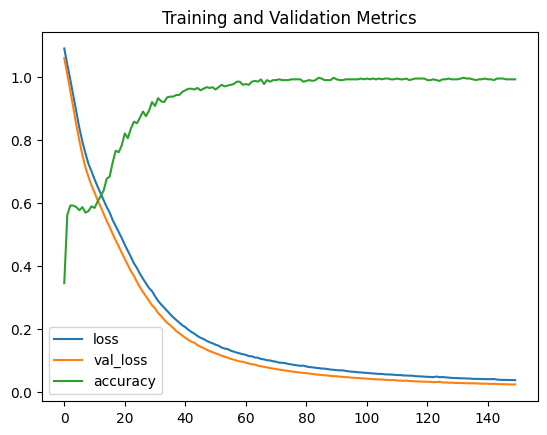

In [ ]:
import pandas as pd

# Evaluate on test partition
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print('Test Accuracy: %.3f' % acc)
z = model.predict(X_test)

# Convert training history to DataFrame and plot learning curves
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss', 'accuracy']].plot()
plt.title('Training and Validation Metrics')
plt.show()

# Interpreting Model Output Probabilities

In [ ]:
# Inspect softmax prediction vector for first sample
z[0]

array([1.509715e-04, 5.121874e-03, 9.947272e-01], dtype=float32)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,561 (33.45 KB)

 Trainable params: 2,853 (11.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,708 (22.30 KB)

/tmp/ipykernel_4410/1987992389.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_test[:, 0], X_test[:, 1], c=z, s=10, cmap=plt.cm.Spectral)


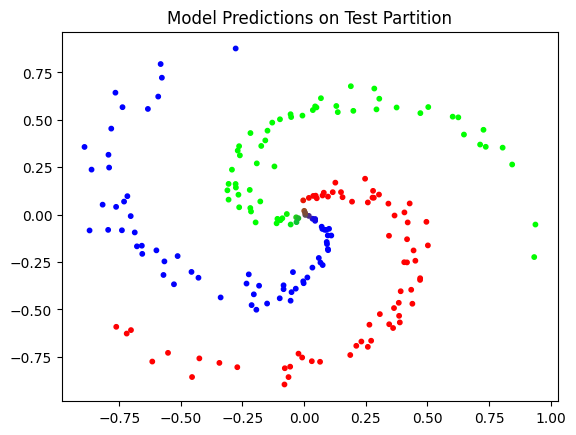

In [ ]:
# Plot test predictions across feature space
plt.scatter(X_test[:, 0], X_test[:, 1], c=z, s=10, cmap=plt.cm.Spectral)
plt.title('Model Predictions on Test Partition')
plt.show()

# Comparison: Model Without Normalized Softmax Activation

In [ ]:
model2 = Sequential()
model2.add(Dense(50, activation='relu', kernel_initializer='glorot_normal', input_shape=(n_features,)))
model2.add(Dense(50, activation='relu', kernel_initializer='glorot_normal'))
model2.add(Dense(3, activation='relu')) # Output layer with ReLU rather than Softmax

# Compile and train model2
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history2 = model2.fit(X_train, y_train, epochs=150, validation_data=(X_test, y_test), batch_size=32, verbose=0)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
z2 = model2.predict(X_test)
print('Softmax output vector: ', z[0], '| Sum of outputs:', z[0].sum())
print('Raw/ReLU output vector: ', z2[0], '| Sum of outputs:', z2[0].sum())
print('True one-hot class label: ', y_test[0])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Softmax output vector:  [1.509715e-04 5.121874e-03 9.947272e-01] | Sum of outputs: 1.0
Raw/ReLU output vector:  [nan nan nan] | Sum of outputs: nan
True one-hot class label:  [0. 0. 1.]
